# 电价预测 EDA — 探索性数据分析

基于 `feature_da.csv` / `feature_rt.csv` 训练集，对目标变量和特征进行深入探索。

**分析框架：**
1. 目标变量分布与日内形态
2. 特征相关性分析
3. 时序特性（ACF/PACF）
4. 缺失模式可视化
5. 特征重要性初筛（RandomForest）
6. 关键发现汇总

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

_CN_FONT_PATHS = [
    "/System/Library/Fonts/Hiragino Sans GB.ttc",
    "/System/Library/Fonts/PingFang.ttc",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/Supplemental/Songti.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
]
for _p in _CN_FONT_PATHS:
    if os.path.exists(_p):
        fm.fontManager.addfont(_p)
        _cn_name = fm.FontProperties(fname=_p).get_name()
        matplotlib.rcParams["font.family"] = "sans-serif"
        matplotlib.rcParams["font.sans-serif"] = [_cn_name]
        print(f"使用中文字体: {_cn_name} ({_p})")
        break
else:
    print("WARNING: 未找到中文字体文件")

matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (14, 5)

OUTPUT_DIR = "../output"
da = pd.read_csv(f"{OUTPUT_DIR}/feature_da.csv", parse_dates=["ts"], index_col="ts")
rt = pd.read_csv(f"{OUTPUT_DIR}/feature_rt.csv", parse_dates=["ts"], index_col="ts")

TARGET_DA = "target_da_clearing_price"
TARGET_RT = "target_rt_clearing_price"

print(f"DA: {da.shape[0]} rows × {da.shape[1]} cols, {da.index.min().date()} ~ {da.index.max().date()}")
print(f"RT: {rt.shape[0]} rows × {rt.shape[1]} cols, {rt.index.min().date()} ~ {rt.index.max().date()}")

使用中文字体: Hiragino Sans GB (/System/Library/Fonts/Hiragino Sans GB.ttc)
DA: 3120 rows × 40 cols, 2025-11-01 ~ 2026-03-10
RT: 3120 rows × 42 cols, 2025-11-01 ~ 2026-03-10


## 1. 目标变量分布

### 1.1 DA / RT 电价基本统计

In [2]:
stats = pd.DataFrame({
    "DA电价": da[TARGET_DA].describe(),
    "RT电价": rt[TARGET_RT].describe(),
})
stats.loc["skew"] = [da[TARGET_DA].skew(), rt[TARGET_RT].skew()]
stats.loc["kurtosis"] = [da[TARGET_DA].kurtosis(), rt[TARGET_RT].kurtosis()]
stats.round(2)

,DA电价,RT电价
count,3120.00,3120.00
mean,421.32,421.88
std,36.67,47.87
min,0.00,0.00
25%,411.46,411.27
50%,424.00,425.81
75%,435.00,441.87
max,608.00,696.79
skew,-4.85,-2.57
kurtosis,47.80,17.30


### 1.2 电价分布直方图 + KDE

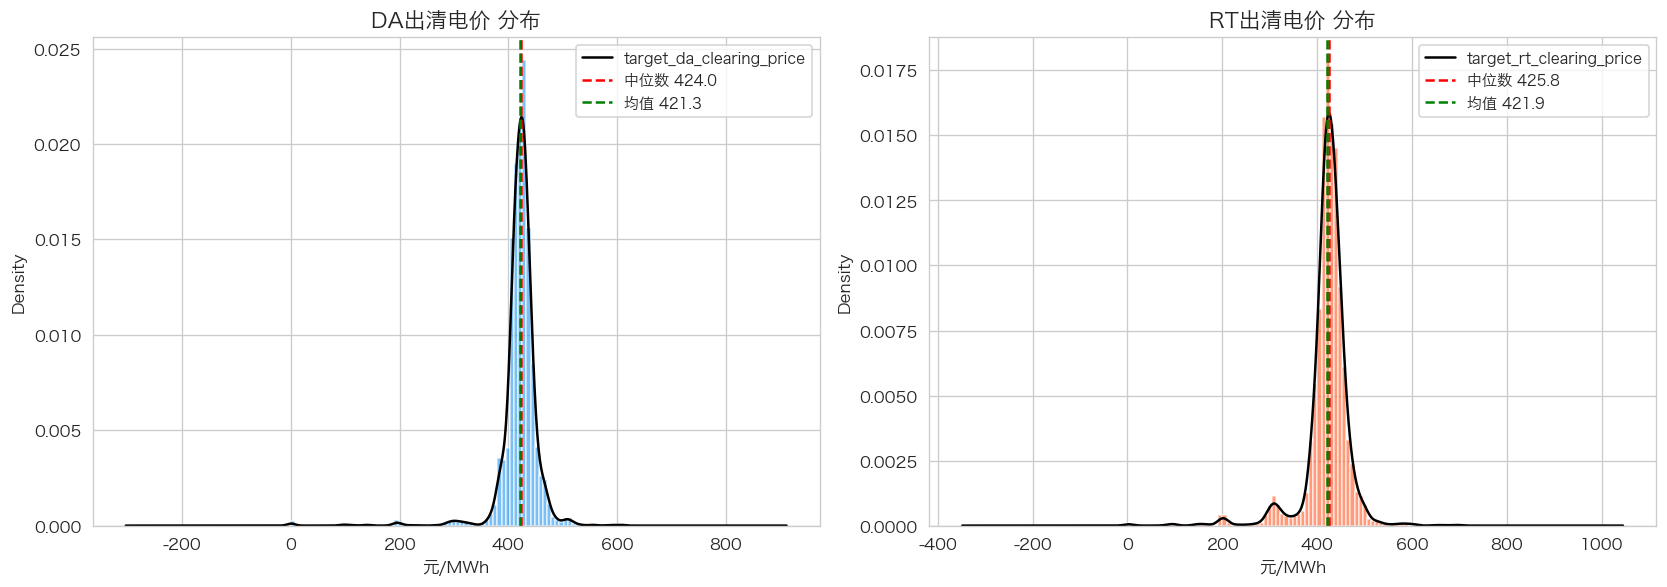

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, series, label, color in [
    (axes[0], da[TARGET_DA], "DA出清电价", "#2196F3"),
    (axes[1], rt[TARGET_RT], "RT出清电价", "#FF5722"),
]:
    ax.hist(series, bins=80, density=True, alpha=0.6, color=color, edgecolor="white")
    series.plot.kde(ax=ax, color="black", linewidth=1.5)
    ax.axvline(series.median(), color="red", ls="--", label=f"中位数 {series.median():.1f}")
    ax.axvline(series.mean(), color="green", ls="--", label=f"均值 {series.mean():.1f}")
    ax.set_title(f"{label} 分布", fontsize=13)
    ax.set_xlabel("元/MWh")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_price_distribution.png", bbox_inches="tight")
plt.show()

### 1.3 日内电价曲线形态（按小时箱线图）

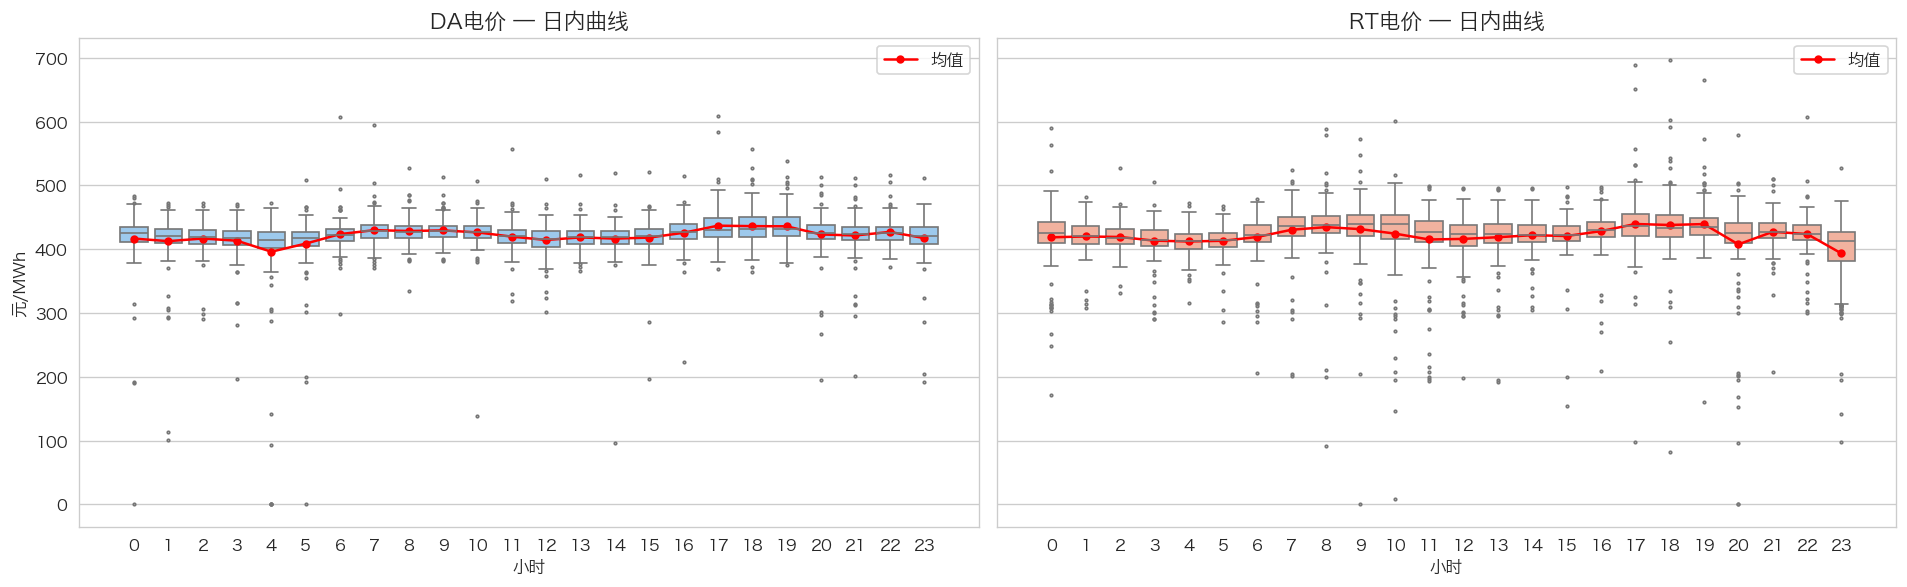

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, df, target, title in [
    (axes[0], da, TARGET_DA, "DA电价 — 日内曲线"),
    (axes[1], rt, TARGET_RT, "RT电价 — 日内曲线"),
]:
    sns.boxplot(data=df, x="hour", y=target, ax=ax, fliersize=1.5,
                color="#90CAF9" if "DA" in title else "#FFAB91")
    hourly_mean = df.groupby("hour")[target].mean()
    ax.plot(range(24), hourly_mean.values, "ro-", markersize=4, linewidth=1.5, label="均值")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("小时")
    ax.set_ylabel("元/MWh")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_intraday_profile.png", bbox_inches="tight")
plt.show()

### 1.4 峰谷时段电价差异

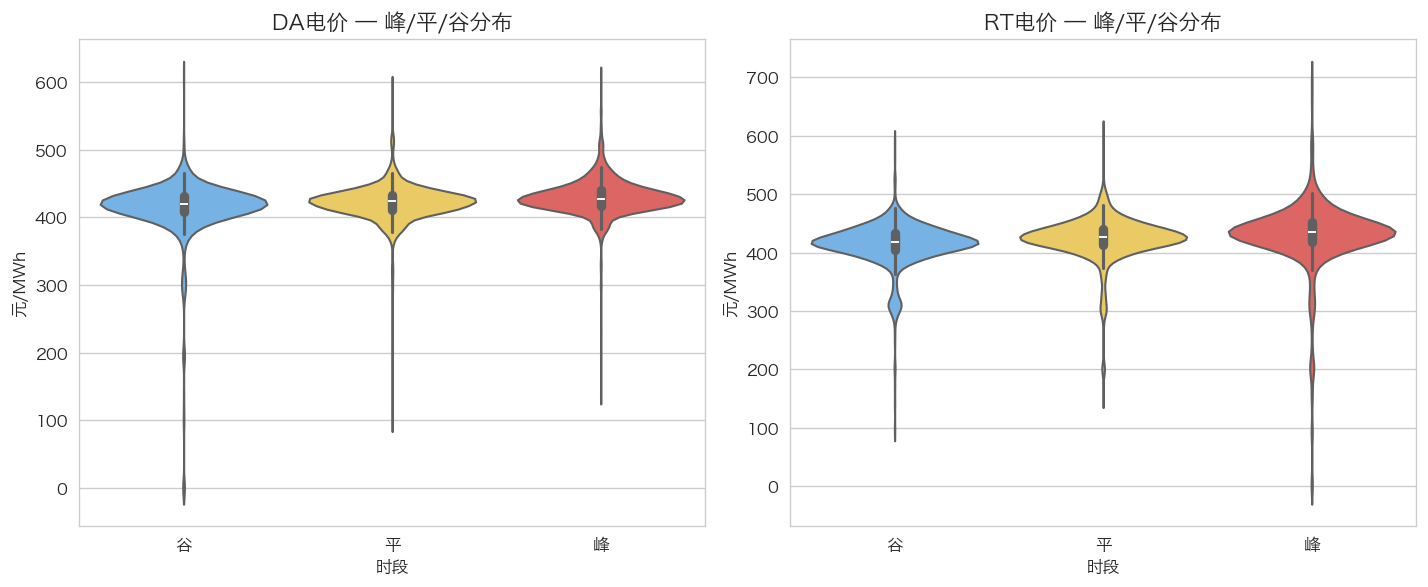

=== DA电价按峰谷统计 ===
          mean    std  median  count
period                              
谷       413.09  48.41  419.43   1040
平       421.42  27.84  423.56   1040
峰       429.44  27.99  427.57   1040

=== RT电价按峰谷统计 ===
          mean    std  median  count
period                              
谷       413.57  38.92  417.75   1040
平       423.36  38.09  426.15   1040
峰       428.70  61.62  434.50   1040


In [5]:
def classify_period(hour):
    if hour in range(8, 12) or hour in range(17, 21):
        return "峰"
    elif hour in range(0, 7) or hour == 23:
        return "谷"
    else:
        return "平"

da["period"] = da["hour"].apply(classify_period)
rt["period"] = rt["hour"].apply(classify_period)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ["谷", "平", "峰"]

for ax, df, target, title in [
    (axes[0], da, TARGET_DA, "DA电价"),
    (axes[1], rt, TARGET_RT, "RT电价"),
]:
    sns.violinplot(data=df, x="period", y=target, order=order, ax=ax,
                   palette=["#64B5F6", "#FFD54F", "#EF5350"], inner="box")
    ax.set_title(f"{title} — 峰/平/谷分布", fontsize=13)
    ax.set_xlabel("时段")
    ax.set_ylabel("元/MWh")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_peak_valley.png", bbox_inches="tight")
plt.show()

print("=== DA电价按峰谷统计 ===")
print(da.groupby("period")[TARGET_DA].agg(["mean", "std", "median", "count"]).loc[order].round(2))
print("\n=== RT电价按峰谷统计 ===")
print(rt.groupby("period")[TARGET_RT].agg(["mean", "std", "median", "count"]).loc[order].round(2))

### 1.5 电价时序走势

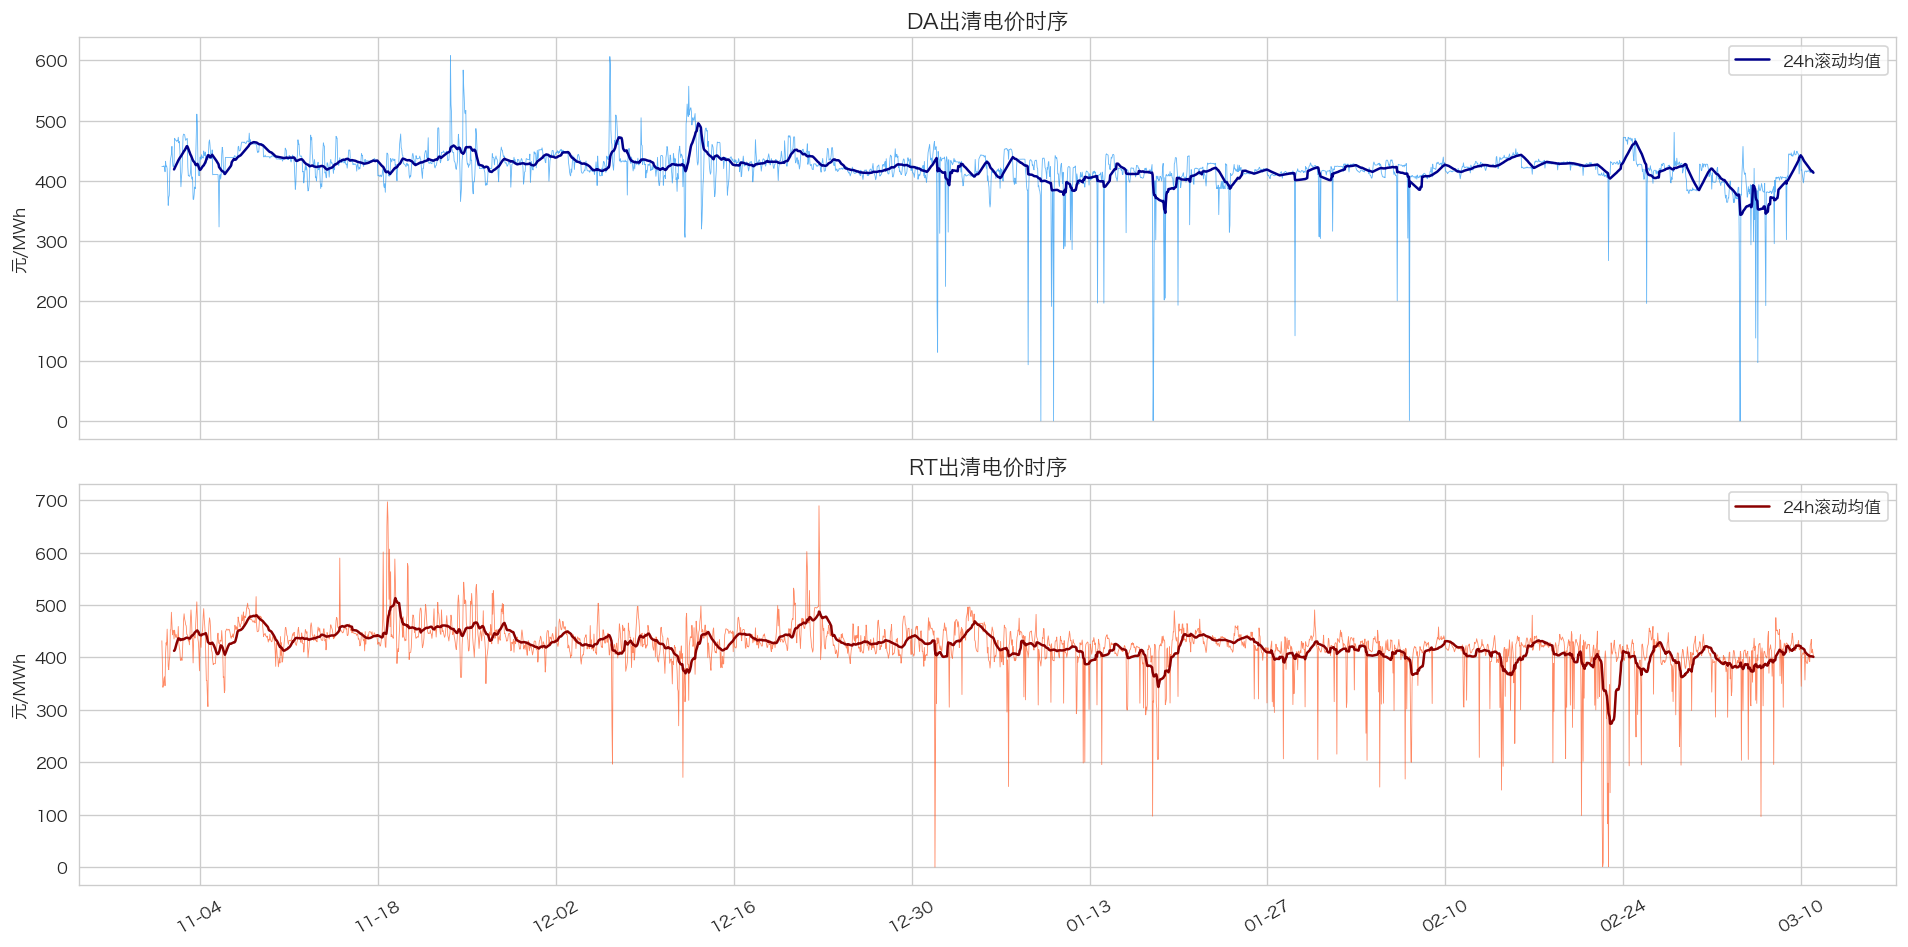

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(da.index, da[TARGET_DA], linewidth=0.5, alpha=0.7, color="#2196F3")
axes[0].plot(da[TARGET_DA].rolling(24).mean(), color="darkblue", linewidth=1.5, label="24h滚动均值")
axes[0].set_title("DA出清电价时序", fontsize=13)
axes[0].set_ylabel("元/MWh")
axes[0].legend()

axes[1].plot(rt.index, rt[TARGET_RT], linewidth=0.5, alpha=0.7, color="#FF5722")
axes[1].plot(rt[TARGET_RT].rolling(24).mean(), color="darkred", linewidth=1.5, label="24h滚动均值")
axes[1].set_title("RT出清电价时序", fontsize=13)
axes[1].set_ylabel("元/MWh")
axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_price_timeseries.png", bbox_inches="tight")
plt.show()

### 1.6 工作日 vs 周末电价对比

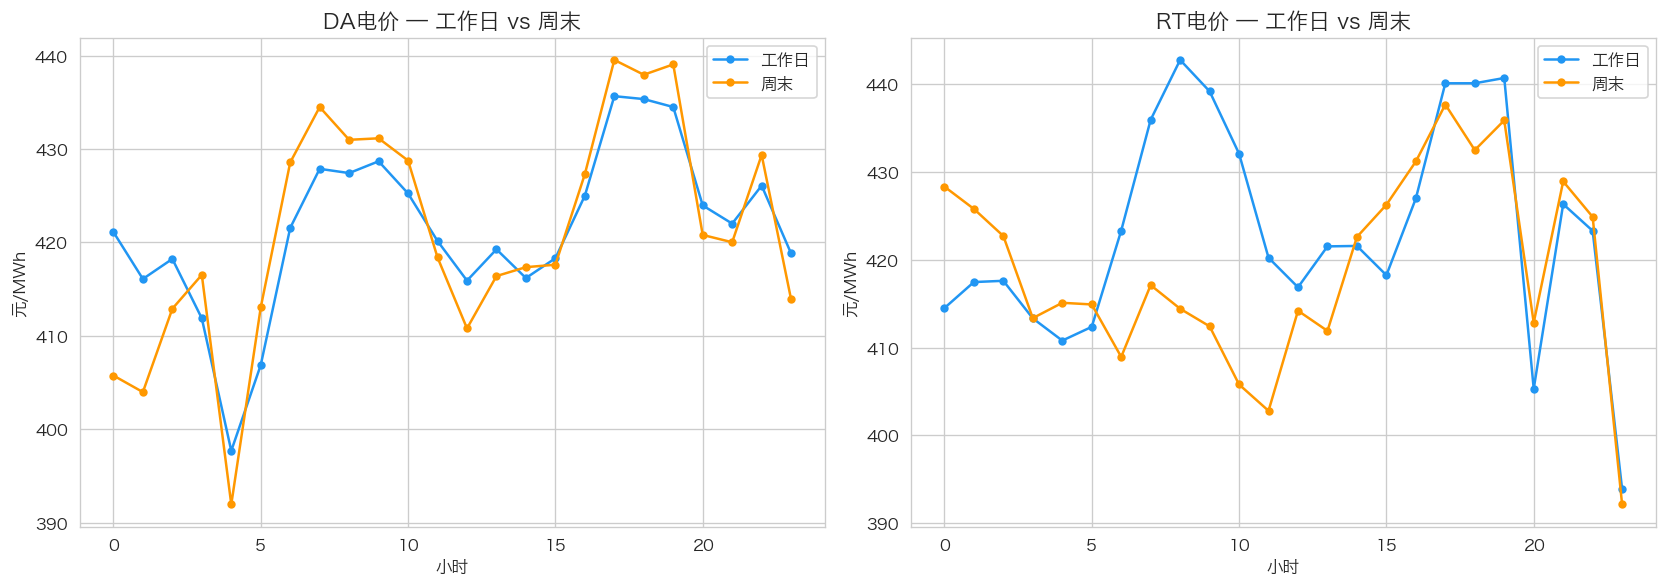

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, target, title in [
    (axes[0], da, TARGET_DA, "DA电价"),
    (axes[1], rt, TARGET_RT, "RT电价"),
]:
    for label, is_wknd, color in [("工作日", 0, "#2196F3"), ("周末", 1, "#FF9800")]:
        sub = df[df["is_weekend"] == is_wknd]
        hourly = sub.groupby("hour")[target].mean()
        ax.plot(hourly.index, hourly.values, "o-", label=label, color=color, markersize=4)
    ax.set_title(f"{title} — 工作日 vs 周末", fontsize=13)
    ax.set_xlabel("小时")
    ax.set_ylabel("元/MWh")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_weekday_weekend.png", bbox_inches="tight")
plt.show()

## 2. 特征相关性分析

### 2.1 与DA目标 Top-15 相关特征

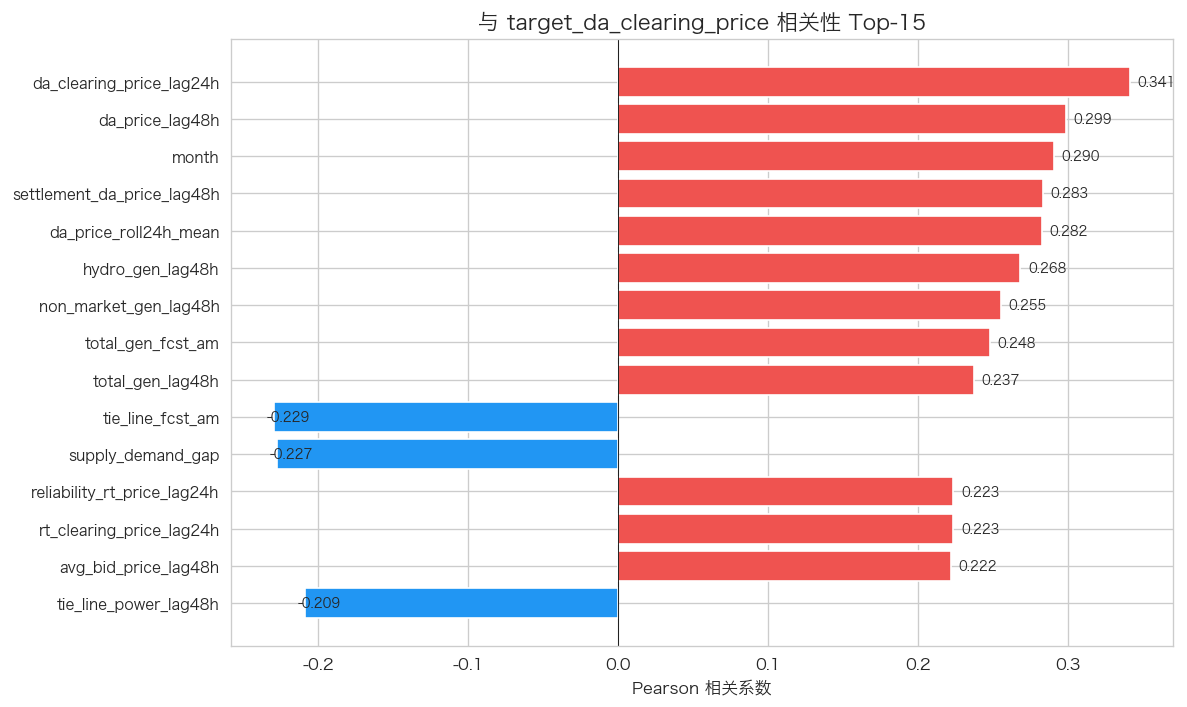

In [8]:
def plot_top_corr(df, target, n=15, title=""):
    feat_cols = [c for c in df.columns if c != target and c != "period"]
    corr = df[feat_cols].corrwith(df[target]).dropna().sort_values(key=abs, ascending=False)
    top = corr.head(n)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#EF5350" if v > 0 else "#2196F3" for v in top.values]
    ax.barh(range(len(top)), top.values, color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Pearson 相关系数")
    ax.set_title(title, fontsize=13)
    ax.axvline(0, color="black", linewidth=0.5)
    for i, v in enumerate(top.values):
        ax.text(v + 0.005 * np.sign(v), i, f"{v:.3f}", va="center", fontsize=8)
    plt.tight_layout()
    return fig, corr

fig_da, corr_da = plot_top_corr(da, TARGET_DA, title=f"与 {TARGET_DA} 相关性 Top-15")
fig_da.savefig(f"{OUTPUT_DIR}/eda_corr_da_top15.png", bbox_inches="tight")
plt.show()

### 2.2 与RT目标 Top-15 相关特征

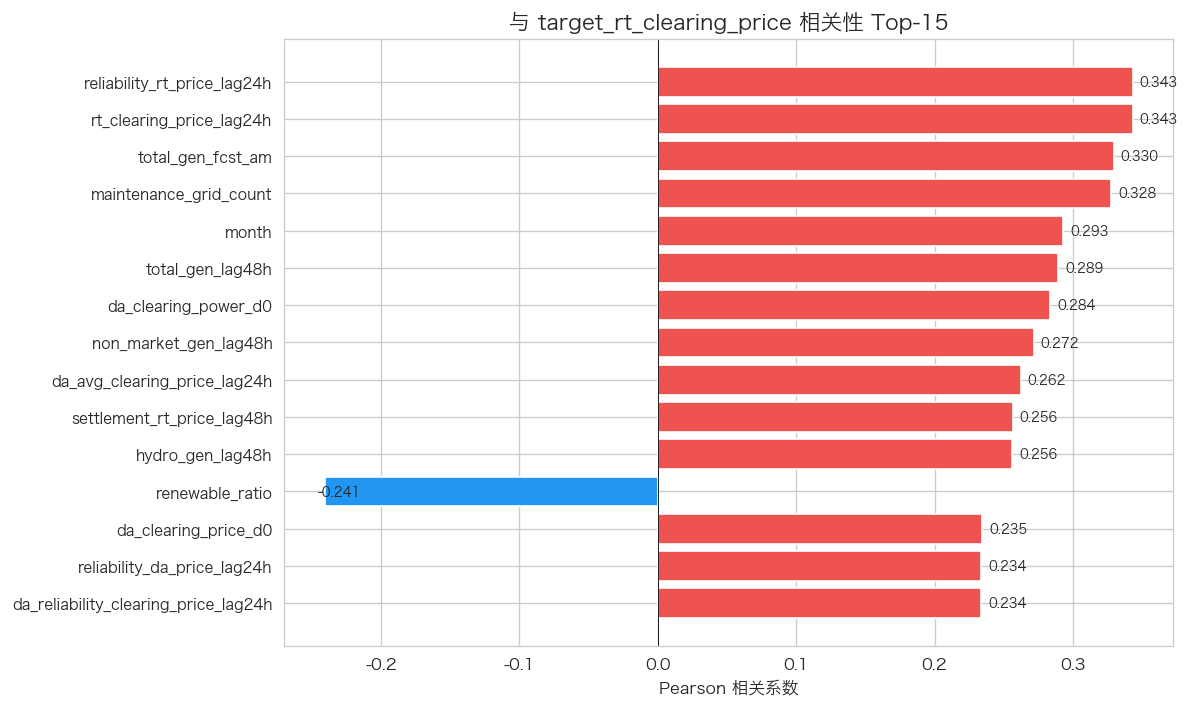

In [9]:
fig_rt, corr_rt = plot_top_corr(rt, TARGET_RT, title=f"与 {TARGET_RT} 相关性 Top-15")
fig_rt.savefig(f"{OUTPUT_DIR}/eda_corr_rt_top15.png", bbox_inches="tight")
plt.show()

### 2.3 核心特征之间相关矩阵热力图

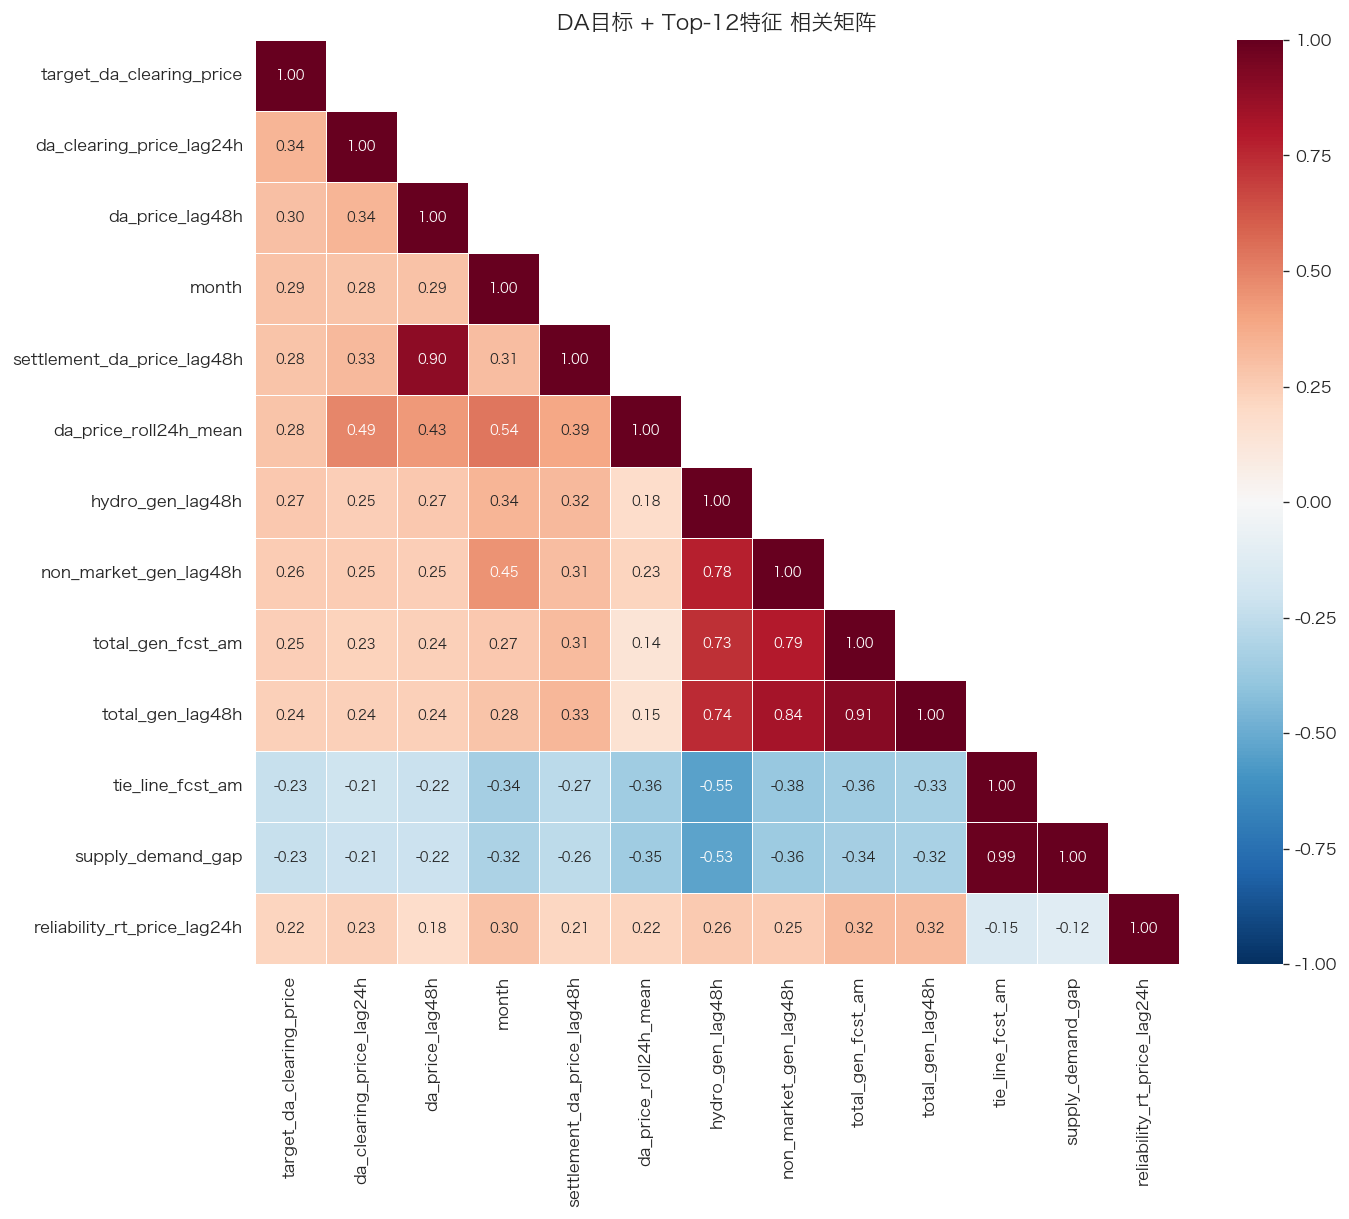

In [10]:
top_da_features = corr_da.abs().sort_values(ascending=False).head(12).index.tolist()
heatmap_cols = [TARGET_DA] + top_da_features
corr_matrix = da[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={"size": 8}, linewidths=0.5)
ax.set_title("DA目标 + Top-12特征 相关矩阵", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_corr_heatmap.png", bbox_inches="tight")
plt.show()

## 3. 时序特性分析

### 3.1 ACF / PACF（DA电价）

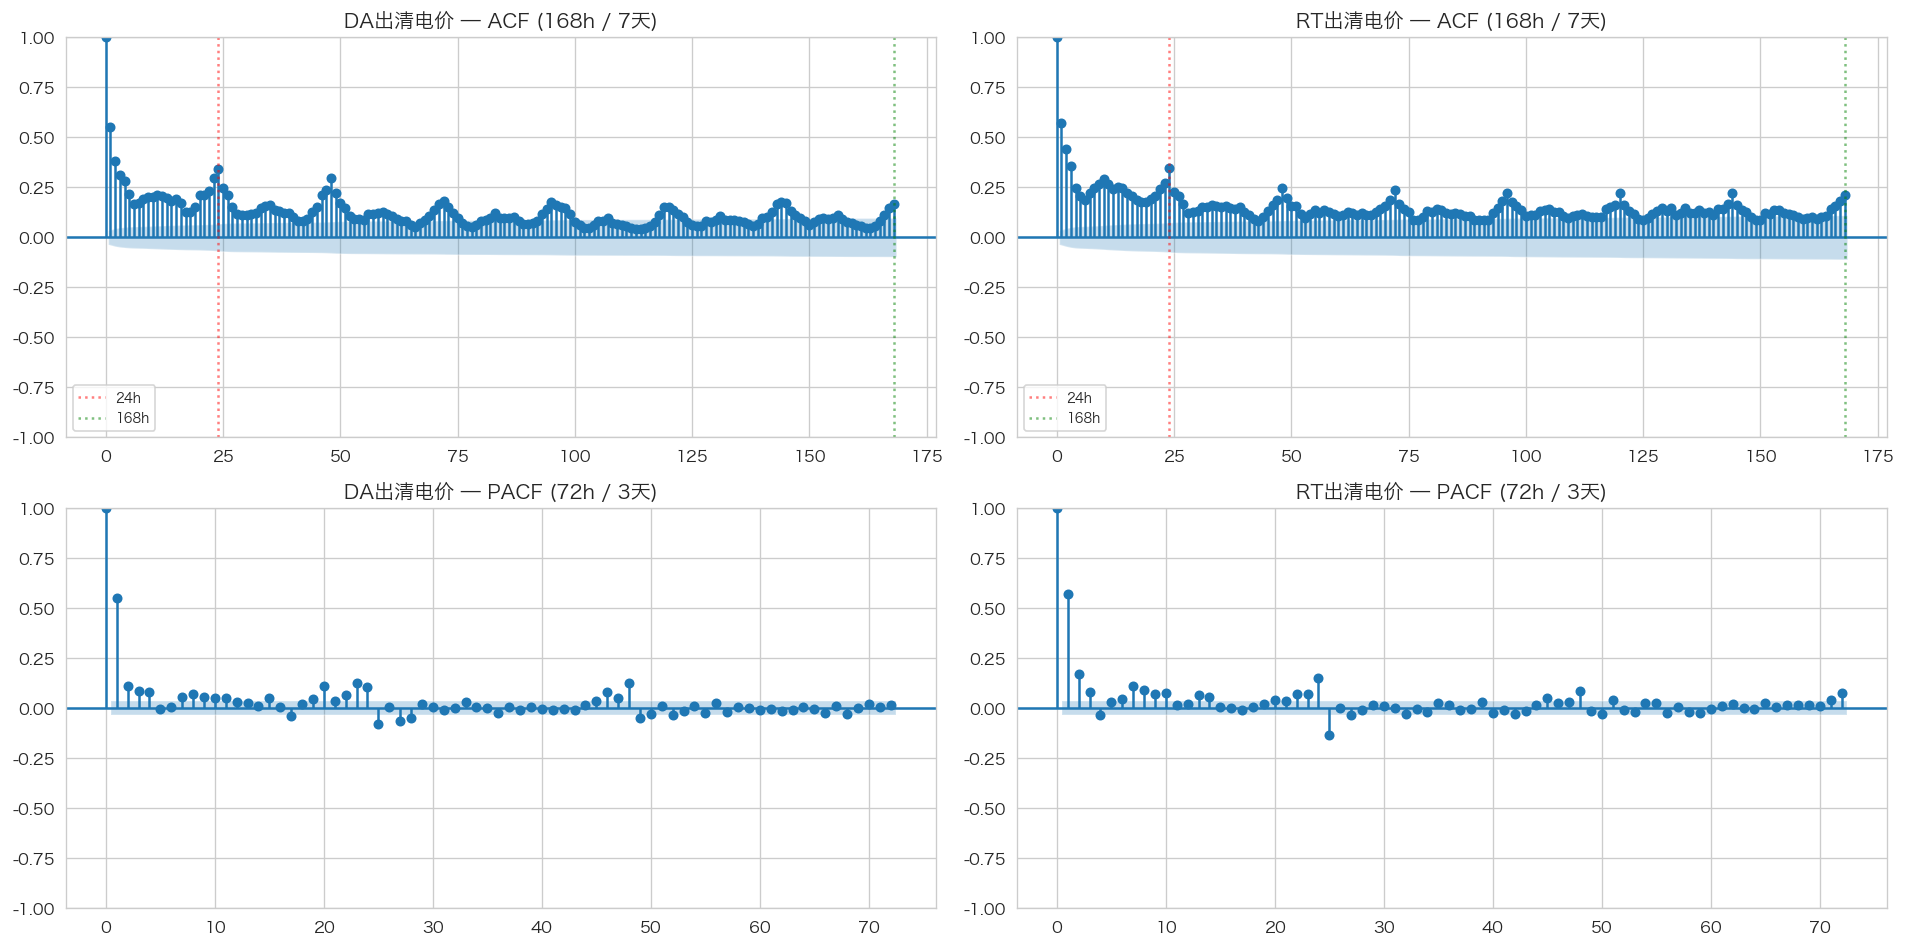

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for col_idx, (series, label) in enumerate([
    (da[TARGET_DA], "DA出清电价"),
    (rt[TARGET_RT], "RT出清电价"),
]):
    plot_acf(series.dropna(), lags=168, ax=axes[0, col_idx], alpha=0.05,
             title=f"{label} — ACF (168h / 7天)")
    plot_pacf(series.dropna(), lags=72, ax=axes[1, col_idx], alpha=0.05,
              method="ywm", title=f"{label} — PACF (72h / 3天)")
    axes[0, col_idx].axvline(24, color="red", ls=":", alpha=0.5, label="24h")
    axes[0, col_idx].axvline(168, color="green", ls=":", alpha=0.5, label="168h")
    axes[0, col_idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_acf_pacf.png", bbox_inches="tight")
plt.show()

### 3.2 日均电价趋势与周期性

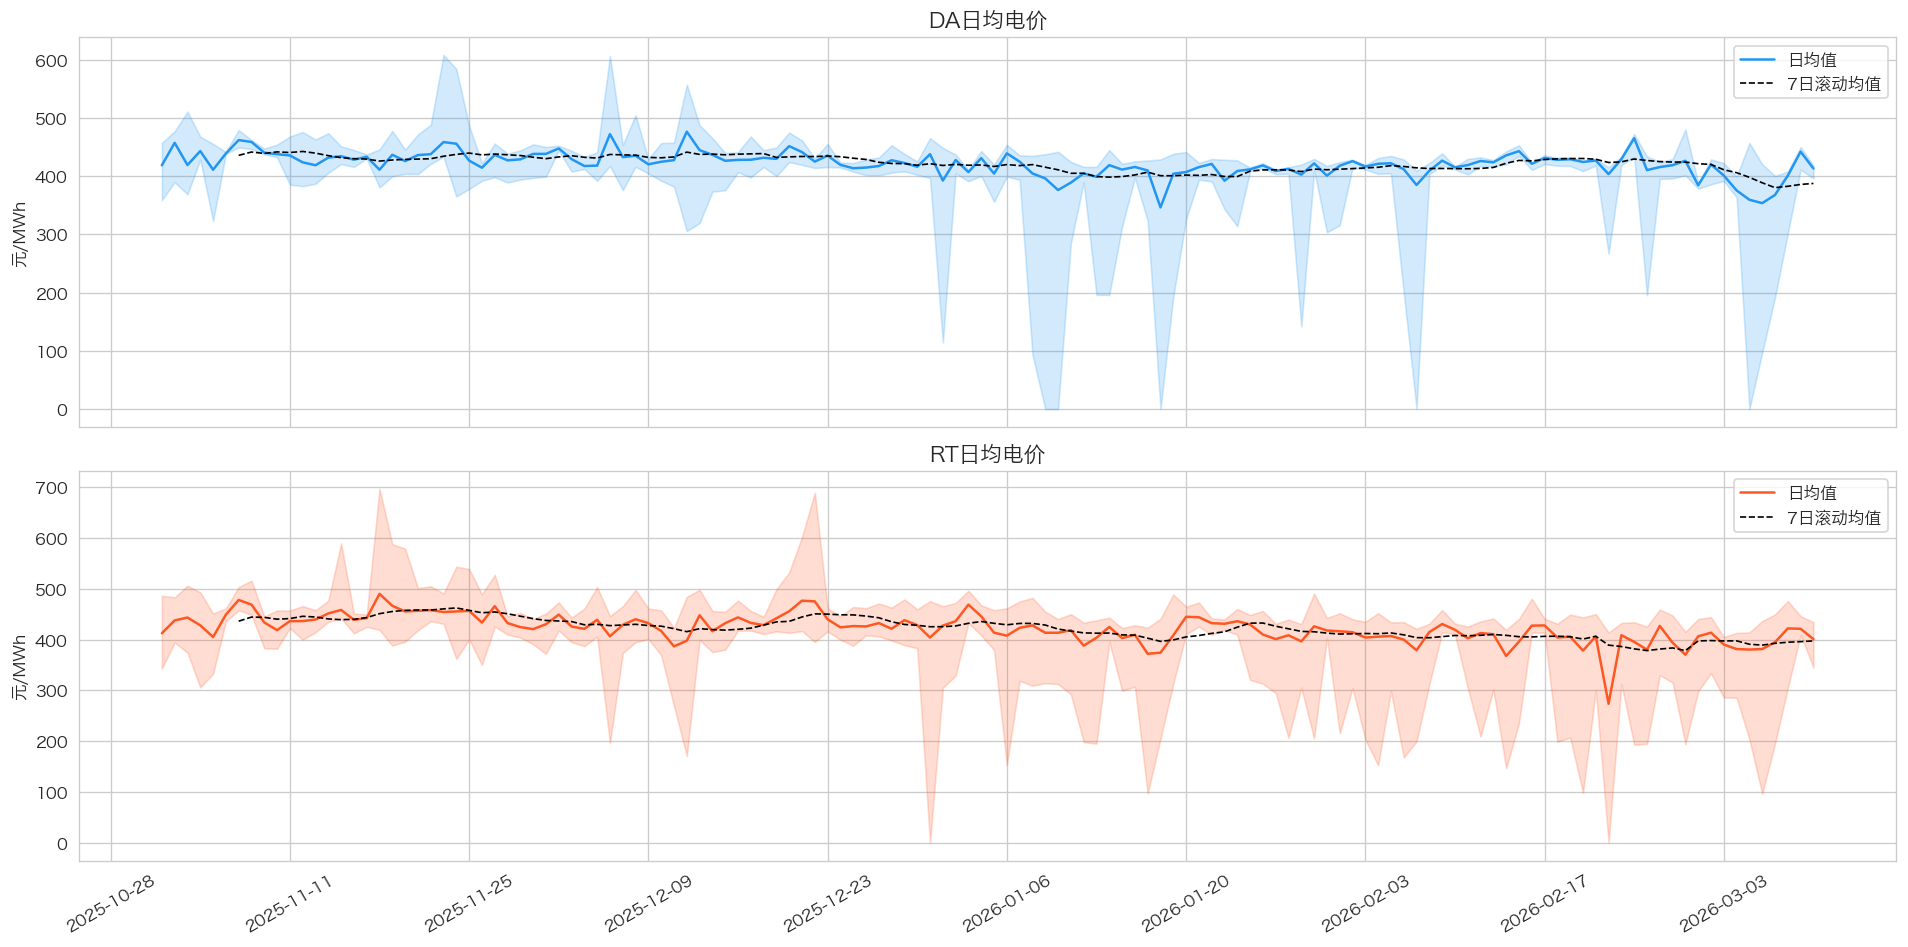

In [12]:
da_daily = da[TARGET_DA].resample("D").agg(["mean", "min", "max"])
rt_daily = rt[TARGET_RT].resample("D").agg(["mean", "min", "max"])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, daily, title, color in [
    (axes[0], da_daily, "DA日均电价", "#2196F3"),
    (axes[1], rt_daily, "RT日均电价", "#FF5722"),
]:
    ax.fill_between(daily.index, daily["min"], daily["max"], alpha=0.2, color=color)
    ax.plot(daily.index, daily["mean"], color=color, linewidth=1.5, label="日均值")
    ax.plot(daily["mean"].rolling(7).mean(), color="black", ls="--", linewidth=1, label="7日滚动均值")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("元/MWh")
    ax.legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_daily_trend.png", bbox_inches="tight")
plt.show()

### 3.3 按星期几分布（周期性验证）

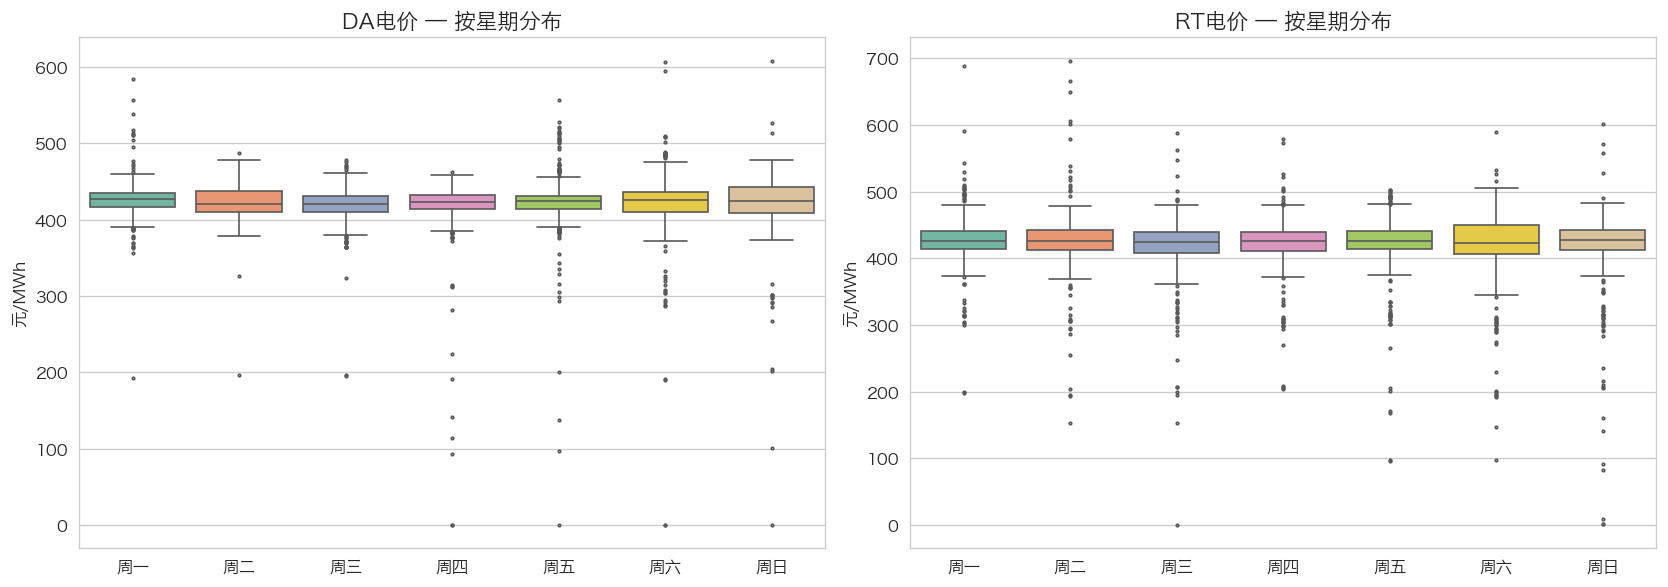

In [13]:
dow_labels = ["周一", "周二", "周三", "周四", "周五", "周六", "周日"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, target, title in [
    (axes[0], da, TARGET_DA, "DA电价"),
    (axes[1], rt, TARGET_RT, "RT电价"),
]:
    sns.boxplot(data=df, x="day_of_week", y=target, ax=ax, fliersize=1.5,
                palette="Set2")
    ax.set_xticklabels(dow_labels)
    ax.set_title(f"{title} — 按星期分布", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("元/MWh")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_weekly_pattern.png", bbox_inches="tight")
plt.show()

## 4. 缺失模式可视化

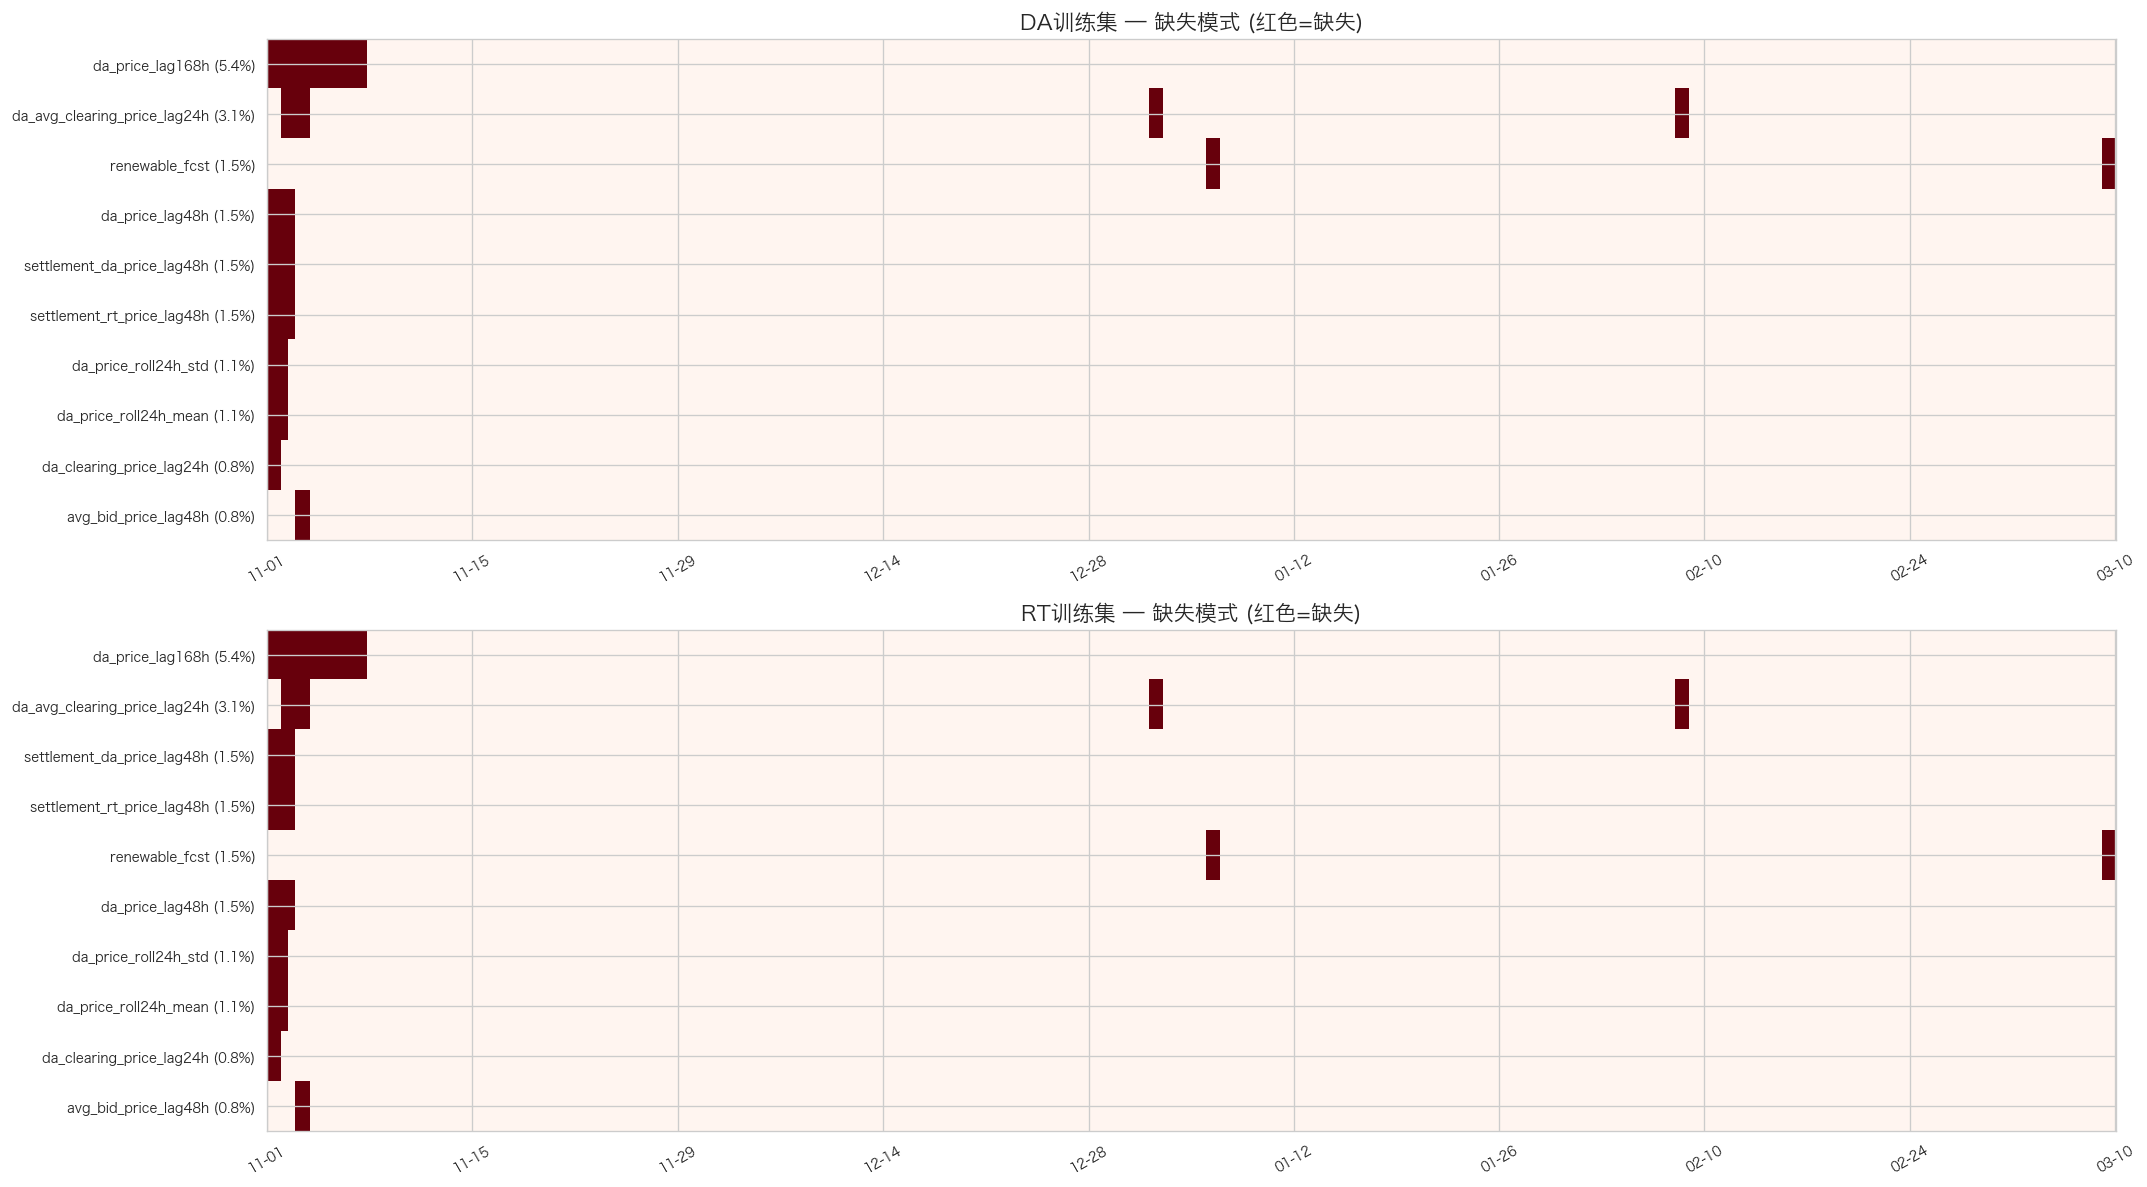

=== DA特征缺失率 ===
da_price_lag168h                5.38%
da_avg_clearing_price_lag24h    3.08%
renewable_fcst                  1.54%
settlement_da_price_lag48h      1.54%
settlement_rt_price_lag48h      1.54%
da_price_lag48h                 1.54%
da_price_roll24h_mean           1.12%
da_price_roll24h_std            1.12%
da_clearing_price_lag24h        0.77%
avg_bid_price_lag48h            0.77%
dtype: object

完整率 >= 95% 的特征: 40/41

=== RT特征缺失率 ===
da_price_lag168h                5.38%
da_avg_clearing_price_lag24h    3.08%
renewable_fcst                  1.54%
settlement_da_price_lag48h      1.54%
settlement_rt_price_lag48h      1.54%
da_price_lag48h                 1.54%
da_price_roll24h_mean           1.12%
da_price_roll24h_std            1.12%
da_clearing_price_lag24h        0.77%
avg_bid_price_lag48h            0.77%
dtype: object

完整率 >= 95% 的特征: 42/43


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for ax, df, label in [(axes[0], da, "DA训练集"), (axes[1], rt, "RT训练集")]:
    feat_cols = [c for c in df.columns if c not in ["period"]]
    missing = df[feat_cols].isnull()
    
    miss_pct = missing.mean().sort_values(ascending=False)
    cols_with_miss = miss_pct[miss_pct > 0].index.tolist()
    
    if len(cols_with_miss) > 0:
        ax.imshow(missing[cols_with_miss].T, aspect="auto", cmap="Reds", interpolation="none")
        ax.set_yticks(range(len(cols_with_miss)))
        ax.set_yticklabels([f"{c} ({miss_pct[c]*100:.1f}%)" for c in cols_with_miss], fontsize=8)
        n_ticks = 10
        tick_positions = np.linspace(0, len(df)-1, n_ticks, dtype=int)
        ax.set_xticks(tick_positions)
        ax.set_xticklabels([df.index[i].strftime("%m-%d") for i in tick_positions], rotation=30, fontsize=8)
    else:
        ax.text(0.5, 0.5, "无缺失值", ha="center", va="center", fontsize=14, transform=ax.transAxes)
    ax.set_title(f"{label} — 缺失模式 (红色=缺失)", fontsize=13)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_missing_pattern.png", bbox_inches="tight")
plt.show()

print("=== DA特征缺失率 ===")
da_miss = da.isnull().mean()
print(da_miss[da_miss > 0].sort_values(ascending=False).apply(lambda x: f"{x*100:.2f}%"))
print(f"\n完整率 >= 95% 的特征: {(da_miss <= 0.05).sum()}/{len(da_miss)}")
print("\n=== RT特征缺失率 ===")
rt_miss = rt.isnull().mean()
print(rt_miss[rt_miss > 0].sort_values(ascending=False).apply(lambda x: f"{x*100:.2f}%"))
print(f"\n完整率 >= 95% 的特征: {(rt_miss <= 0.05).sum()}/{len(rt_miss)}")

## 5. 特征重要性初筛（RandomForest）

### 5.1 DA电价特征重要性

RF in-sample R²: 0.5826 (仅供参考，非泛化性能)
使用 2856 行完整数据


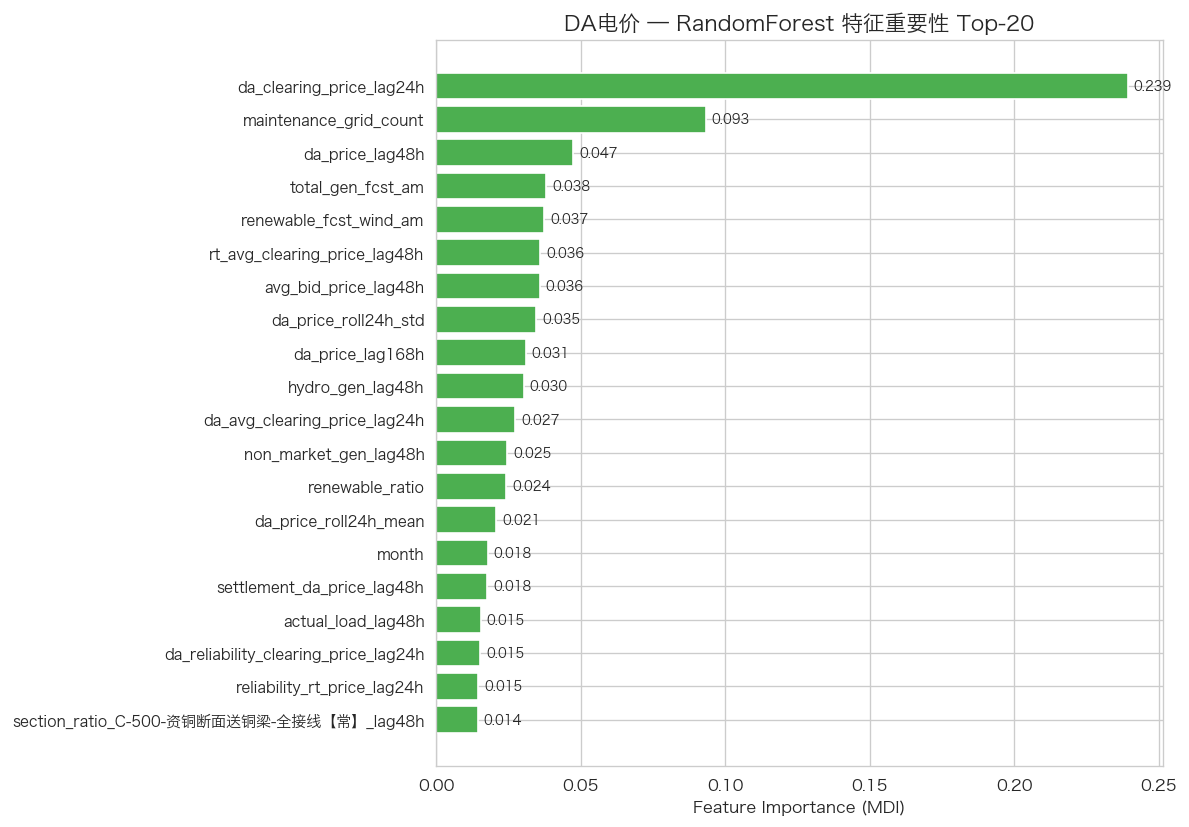

In [15]:
def rf_feature_importance(df, target, n_top=20, title=""):
    """用RandomForest快速评估特征重要性。"""
    feat_cols = [c for c in df.columns if c != target and c != "period"]
    sub = df[feat_cols + [target]].dropna()
    X = sub[feat_cols]
    y = sub[target]

    rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=10,
                               random_state=42, n_jobs=-1)
    rf.fit(X, y)

    imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
    top = imp.head(n_top)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(top)), top.values, color="#4CAF50")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance (MDI)")
    ax.set_title(title, fontsize=13)
    for i, v in enumerate(top.values):
        ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
    plt.tight_layout()

    r2 = rf.score(X, y)
    print(f"RF in-sample R²: {r2:.4f} (仅供参考，非泛化性能)")
    print(f"使用 {len(sub)} 行完整数据")

    return fig, imp, rf

fig_imp_da, imp_da, rf_da = rf_feature_importance(
    da, TARGET_DA, title="DA电价 — RandomForest 特征重要性 Top-20"
)
fig_imp_da.savefig(f"{OUTPUT_DIR}/eda_rf_importance_da.png", bbox_inches="tight")
plt.show()

### 5.2 RT电价特征重要性

RF in-sample R²: 0.6023 (仅供参考，非泛化性能)
使用 2856 行完整数据


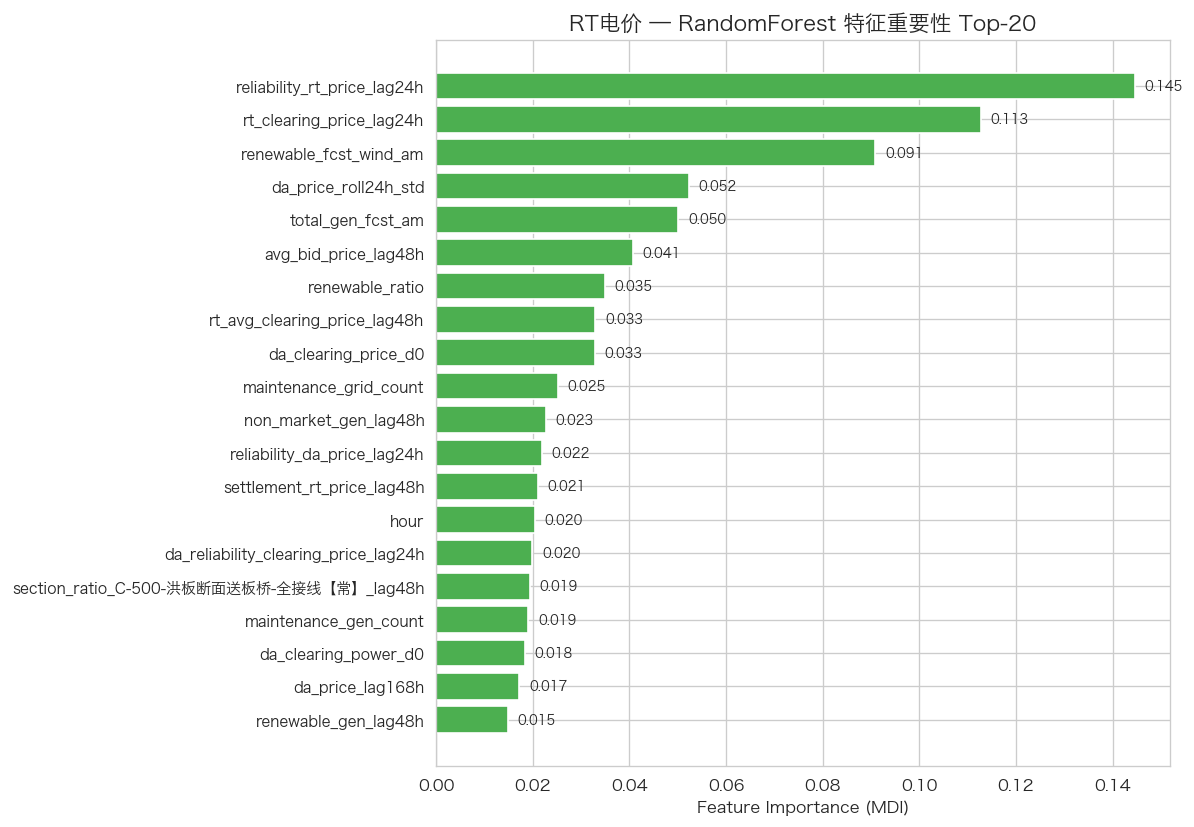

In [16]:
fig_imp_rt, imp_rt, rf_rt = rf_feature_importance(
    rt, TARGET_RT, title="RT电价 — RandomForest 特征重要性 Top-20"
)
fig_imp_rt.savefig(f"{OUTPUT_DIR}/eda_rf_importance_rt.png", bbox_inches="tight")
plt.show()

### 5.3 DA vs RT 特征重要性对比

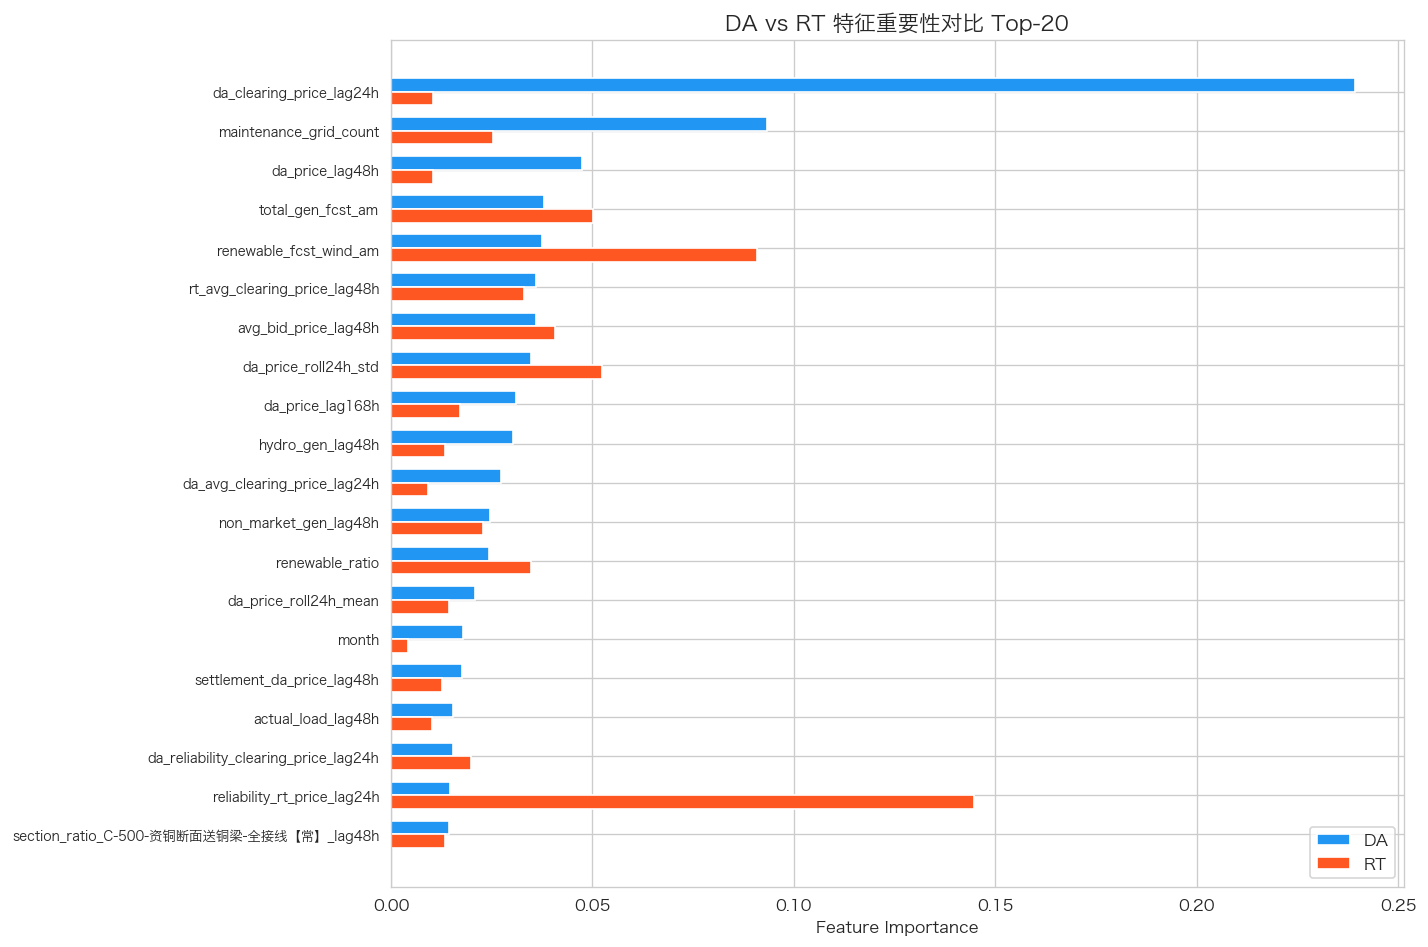

In [17]:
common_feats = sorted(set(imp_da.index) & set(imp_rt.index))
comparison = pd.DataFrame({
    "DA_importance": imp_da[common_feats],
    "RT_importance": imp_rt[common_feats],
}).dropna()
comparison["diff"] = comparison["DA_importance"] - comparison["RT_importance"]
comparison = comparison.sort_values("DA_importance", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_common = comparison.head(20)
x = np.arange(len(top_common))
width = 0.35
ax.barh(x - width/2, top_common["DA_importance"], width, label="DA", color="#2196F3")
ax.barh(x + width/2, top_common["RT_importance"], width, label="RT", color="#FF5722")
ax.set_yticks(x)
ax.set_yticklabels(top_common.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("DA vs RT 特征重要性对比 Top-20", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_rf_importance_compare.png", bbox_inches="tight")
plt.show()

## 6. 关键特征散点图

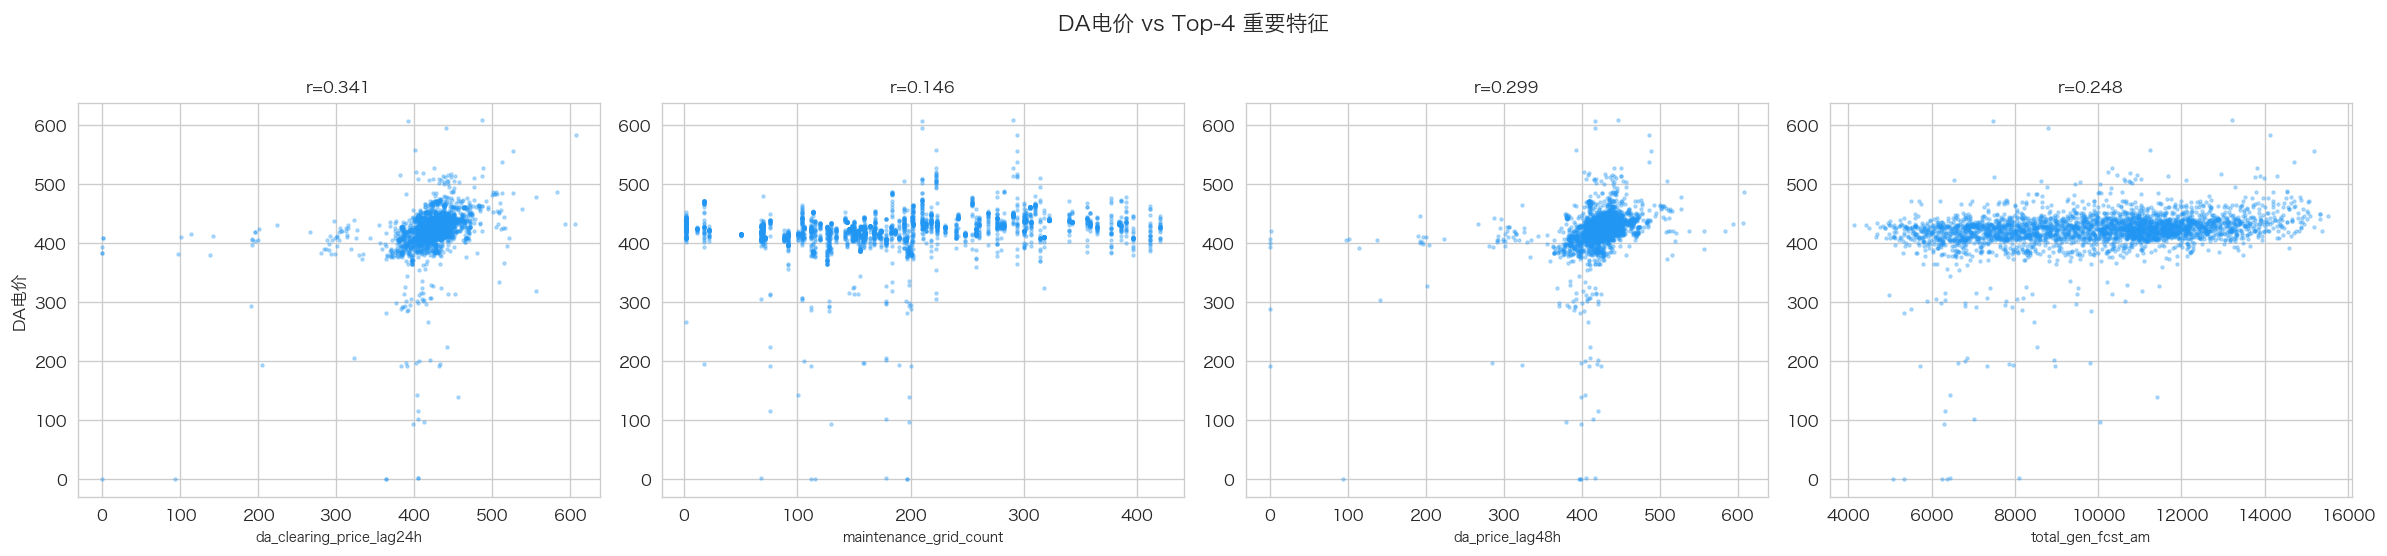

In [18]:
top4_da = imp_da.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, feat in zip(axes, top4_da):
    valid = da[[feat, TARGET_DA]].dropna()
    ax.scatter(valid[feat], valid[TARGET_DA], s=3, alpha=0.3, c="#2196F3")
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel("DA电价" if ax == axes[0] else "")
    r = valid[feat].corr(valid[TARGET_DA])
    ax.set_title(f"r={r:.3f}", fontsize=10)

plt.suptitle("DA电价 vs Top-4 重要特征", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_scatter_top4.png", bbox_inches="tight")
plt.show()

## 7. 关键发现汇总

In [19]:
print("=" * 70)
print("EDA 关键发现汇总")
print("=" * 70)

print("\n【1. 数据概况】")
print(f"  - DA训练集: {da.shape[0]} 行 × {da.shape[1]} 列")
print(f"  - RT训练集: {rt.shape[0]} 行 × {rt.shape[1]} 列")
print(f"  - 有效窗口: {da.index.min().date()} ~ {da.index.max().date()} ({(da.index.max() - da.index.min()).days} 天)")

print("\n【2. 目标变量特征】")
print(f"  - DA电价均值: {da[TARGET_DA].mean():.1f}, 标准差: {da[TARGET_DA].std():.1f}, 偏度: {da[TARGET_DA].skew():.2f}")
print(f"  - RT电价均值: {rt[TARGET_RT].mean():.1f}, 标准差: {rt[TARGET_RT].std():.1f}, 偏度: {rt[TARGET_RT].skew():.2f}")
da_peak = da[da['period']=='峰'][TARGET_DA].mean()
da_valley = da[da['period']=='谷'][TARGET_DA].mean()
print(f"  - DA峰谷价差: 峰 {da_peak:.1f} vs 谷 {da_valley:.1f} (差 {da_peak - da_valley:.1f} 元/MWh)")

print("\n【3. 时序特性】")
print("  - ACF图显示明显的24h周期性（日内模式），168h处有弱周相关")
print("  - PACF在lag1~3最显著，说明短期自回归结构强")

print("\n【4. 最相关特征 (Top-5)】")
print("  DA:")
for name, val in corr_da.abs().sort_values(ascending=False).head(5).items():
    print(f"    {name}: {val:.4f}")
print("  RT:")
for name, val in corr_rt.abs().sort_values(ascending=False).head(5).items():
    print(f"    {name}: {val:.4f}")

print("\n【5. RF特征重要性 (Top-5)】")
print("  DA:")
for name, val in imp_da.head(5).items():
    print(f"    {name}: {val:.4f}")
print("  RT:")
for name, val in imp_rt.head(5).items():
    print(f"    {name}: {val:.4f}")

print("\n【6. 缺失情况】")
da_miss_count = (da.isnull().mean() > 0).sum()
rt_miss_count = (rt.isnull().mean() > 0).sum()
print(f"  - DA: {da_miss_count} 个特征有缺失值")
print(f"  - RT: {rt_miss_count} 个特征有缺失值")
print(f"  - 所有特征覆盖率 >= 94.6%")

print("\n【7. 建模建议】")
print("  - 价格滞后特征(lag24h, lag48h)和滚动统计量是最重要的预测信号")
print("  - 供需侧特征(总出力预测、联络线、检修)提供了有价值的外生信息")
print("  - 日历特征(hour, month, day_of_week)捕捉季节性和日内模式")
print("  - RT模型中的DA出清价(lag0)是独有且重要的特征")
print("  - 建议在基线模型中使用全部特征，后续再通过SHAP做精细筛选")

EDA 关键发现汇总

【1. 数据概况】
  - DA训练集: 3120 行 × 41 列
  - RT训练集: 3120 行 × 43 列
  - 有效窗口: 2025-11-01 ~ 2026-03-10 (129 天)

【2. 目标变量特征】
  - DA电价均值: 421.3, 标准差: 36.7, 偏度: -4.85
  - RT电价均值: 421.9, 标准差: 47.9, 偏度: -2.57
  - DA峰谷价差: 峰 429.4 vs 谷 413.1 (差 16.4 元/MWh)

【3. 时序特性】
  - ACF图显示明显的24h周期性（日内模式），168h处有弱周相关
  - PACF在lag1~3最显著，说明短期自回归结构强

【4. 最相关特征 (Top-5)】
  DA:
    da_clearing_price_lag24h: 0.3410
    da_price_lag48h: 0.2985
    month: 0.2903
    settlement_da_price_lag48h: 0.2830
    da_price_roll24h_mean: 0.2824
  RT:
    reliability_rt_price_lag24h: 0.3431
    rt_clearing_price_lag24h: 0.3431
    total_gen_fcst_am: 0.3296
    maintenance_grid_count: 0.3278
    month: 0.2929

【5. RF特征重要性 (Top-5)】
  DA:
    da_clearing_price_lag24h: 0.2394
    maintenance_grid_count: 0.0933
    da_price_lag48h: 0.0474
    total_gen_fcst_am: 0.0381
    renewable_fcst_wind_am: 0.0374
  RT:
    reliability_rt_price_lag24h: 0.1446
    rt_clearing_price_lag24h: 0.1127
    renewable_fcst_wind_am: 0.0909
    da_pri